# InsightForge: AI-Powered Business Intelligence Assistant
**UCSB PaCE: Advanced Generative AI Capstone**

InsightForge helps small and medium-sized businesses turn raw sales data into insight. It uses
**LangChain**, **Retrieval-Augmented Generation (RAG)** and an **LLM** to:

1. **Analyze business data**: identify key trends and patterns
2. **Generate insights and recommendations**: answer questions in natural language
3. **Visualize data insights**: charts that are easy to interpret

**Design decision:** the LLM is never asked to do arithmetic. Pandas computes every statistic and a
custom retriever passes only the relevant figures to the LLM, which explains them. This keeps the
numbers accurate and makes the answers traceable.

| Part | Step | Section |
|---|---|---|
| 1 | Data preparation | 1 |
| 1 | Knowledge base creation | 2 |
| 1 | LLM application development (advanced summary, custom retriever, prompt engineering) | 3 |
| 1 | Chain prompts | 4 |
| 1 | RAG system setup | 5 |
| 1 | Memory integration | 6 |
| 2 | Model evaluation (QAEvalChain) | 7 |
| 2 | Monitoring (latency, tokens, cost) | 7.1 |
| 2 | Data visualization | 8 |
| 2 | Streamlit UI | 9 (`app.py`) |

## 0. Setup

In [1]:
# !pip install -r requirements.txt   # uncomment on first run

%matplotlib inline
import os, warnings
warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import display, Markdown

import insightforge as ifg

# The OpenAI key is read from the environment or a local .env file (OPENAI_API_KEY=sk-...),
# loaded by insightforge on import. Never hard-code it in the notebook.
USE_OPENAI = bool(os.getenv("OPENAI_API_KEY"))
print("LLM backend:", "OpenAI gpt-4o-mini" if USE_OPENAI else "DEMO MODE (no API key found - placeholder responses)")

LLM backend: OpenAI gpt-4o-mini


## 1. Data preparation
The dataset is pre-prepared (no cleaning required), so this step only loads it and adds analysis
helper columns: `Year`, `Quarter`, `Month`, `Month_Name` and `Age_Group`.

In [2]:
df = ifg.load_data()
print(df.shape)
display(df.head())
df.info()

(2500, 12)


,Date,Product,Region,Sales,Customer_Age,Customer_Gender,Customer_Satisfaction,Year,Quarter,Month,Month_Name,Age_Group
0,2022-01-01,Widget C,South,786,26,Male,2.874407,2022,2022Q1,2022-01,January,25-34
1,2022-01-02,Widget D,East,850,29,Male,3.365205,2022,2022Q1,2022-01,January,25-34
2,2022-01-03,Widget A,North,871,40,Female,4.547364,2022,2022Q1,2022-01,January,35-44
3,2022-01-04,Widget C,South,464,31,Male,4.555420,2022,2022Q1,2022-01,January,25-34
4,2022-01-05,Widget C,South,262,50,Female,3.982935,2022,2022Q1,2022-01,January,45-54


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   2500 non-null   datetime64[us]
 1   Product                2500 non-null   str           
 2   Region                 2500 non-null   str           
 3   Sales                  2500 non-null   int64         
 4   Customer_Age           2500 non-null   int64         
 5   Customer_Gender        2500 non-null   str           
 6   Customer_Satisfaction  2500 non-null   float64       
 7   Year                   2500 non-null   int32         
 8   Quarter                2500 non-null   str           
 9   Month                  2500 non-null   str           
 10  Month_Name             2500 non-null   str           
 11  Age_Group              2500 non-null   category      
dtypes: category(1), datetime64[us](1), float64(1), int32(1), int64(2), str(6)

In [3]:
print("Missing values:\n", df.isna().sum().to_string())
print("\nDate range:", df["Date"].min().date(), "->", df["Date"].max().date())
display(df.describe(include="all").T)

Missing values:
 Date                     0
Product                  0
Region                   0
Sales                    0
Customer_Age             0
Customer_Gender          0
Customer_Satisfaction    0
Year                     0
Quarter                  0
Month                    0
Month_Name               0
Age_Group                0

Date range: 2022-01-01 -> 2028-11-04


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,2500,NaN,NaN,NaN,2025-06-03 12:00:00,2022-01-01 00:00:00,2023-09-17 18:00:00,2025-06-03 12:00:00,2027-02-18 06:00:00,2028-11-04 00:00:00,NaN
Product,2500,4,Widget A,656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,2500,4,West,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales,2500.0,NaN,NaN,NaN,553.288,100.0,324.75,552.5,779.0,999.0,260.101758
Customer_Age,2500.0,NaN,NaN,NaN,43.3328,18.0,31.0,43.0,56.0,69.0,14.846758
Customer_Gender,2500,2,Female,1256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Satisfaction,2500.0,NaN,NaN,NaN,3.025869,1.005422,2.056014,3.04948,4.042481,4.999006,1.156981
Year,2500.0,NaN,NaN,NaN,2024.9324,2022.0,2023.0,2025.0,2027.0,2028.0,1.970732
Quarter,2500,28,2022Q3,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,2500,83,2022-01,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Knowledge base creation
The data is organized into a structured, retrievable form: each business topic (time, product,
region, demographics, statistics) becomes one LangChain `Document` with `topic` metadata.

In [4]:
knowledge_base = ifg.build_knowledge_base(df)
print(f"{len(knowledge_base)} knowledge-base documents:")
for d in knowledge_base:
    print(" -", d.metadata["topic"])

12 knowledge-base documents:
 - overview
 - time_yearly
 - time_quarterly
 - time_monthly
 - product
 - region
 - product_region
 - product_satisfaction
 - gender
 - age
 - segment
 - statistics


## 3. LLM application development
### 3.1 Advanced data summary
Key metrics and trends computed with pandas.

**Overview**

In [5]:
summaries = ifg.compute_summaries(df)
print(summaries['overview'])

Dataset covers 2500 transactions from 2022-01-01 to 2028-11-04.
Products: Widget A, Widget B, Widget C, Widget D. Regions: East, North, South, West.
Total sales: 1,383,220.
Sales per transaction: mean=553.29, median=552.50, std=260.10, min=100.00, max=999.00.
Customer age: mean=43.33, median=43.00, std=14.85, min=18.00, max=69.00.
Customer satisfaction (1-5): mean=3.03, median=3.05, std=1.16, min=1.01, max=5.00.


**Sales performance by time period**

In [6]:
print(summaries['time_yearly']); print(); print(summaries['time_monthly'])

Sales by year:
       total  average  median  std_dev  transactions
Year                                                
2022  200657   549.75   555.0   268.77           365
2023  202259   554.13   570.0   250.38           365
2024  195458   534.04   519.0   264.04           366
2025  203906   558.65   578.0   256.09           365
2026  206175   564.86   569.0   258.47           365
2027  195154   534.67   519.0   259.79           365
2028  179611   581.27   580.0   262.22           309

Year-over-year growth of total sales (%):
Year
2022    NaN
2023    0.8
2024   -3.4
2025    4.3
2026    1.1
2027   -5.3
2028   -8.0
Note: the first and last years may be partial years.

Monthly total sales (complete months only; partial months at the edges of the data are excluded): best month 2028-04 (20,387), worst month 2022-04 (13,376), average month 16,829.
Sales by calendar month (all years combined, seasonality):
             total  average  median  std_dev  transactions
Month_Name               

In [7]:
print(summaries['time_quarterly'])

Sales by quarter:
         total  average  median  std_dev  transactions
Quarter                                               
2022Q1   48268   536.31   498.0   266.84            90
2022Q2   45809   503.40   502.0   265.69            91
2022Q3   54719   594.77   633.5   264.38            92
2022Q4   51861   563.71   612.5   273.91            92
2023Q1   46086   512.07   547.5   232.04            90
2023Q2   52010   571.54   591.0   247.05            91
2023Q3   51459   559.34   596.0   269.23            92
2023Q4   52704   572.87   572.0   250.64            92
2024Q1   50623   556.30   579.0   267.39            91
2024Q2   49652   545.63   550.0   265.06            91
2024Q3   48010   521.85   517.5   253.63            92
2024Q4   47173   512.75   477.0   271.80            92
2025Q1   52868   587.42   609.5   247.85            90
2025Q2   49916   548.53   554.0   268.63            91
2025Q3   47377   514.97   512.0   243.08            92
2025Q4   53745   584.18   611.5   261.32       

**Product and regional analysis**

In [8]:
print(summaries['product']); print(); print(summaries['region']); print(); print(summaries['product_region'])

Sales by product:
           total  average  median  std_dev  transactions
Product                                                 
Widget A  375235   572.00   582.0   257.58           656
Widget B  346062   565.46   570.0   260.21           612
Widget C  335069   540.43   541.5   263.98           620
Widget D  326854   534.08   536.0   257.30           612

Sales by region:
         total  average  median  std_dev  transactions
Region                                                
East    320296   543.80   544.0   255.65           589
North   353025   552.46   551.0   258.68           639
South   348516   554.96   552.0   260.62           628
West    361383   561.15   571.0   265.31           644

ANSWER TO 'which product sells best and where': Widget A is the best-selling product overall (375,235); it sells best in the South (99,603). Widget A by region, high to low: South 99,603, West 95,375, North 90,965, East 89,292.
Highest-selling product-region combination: Widget A in South (

**Customer segmentation by demographics**

In [9]:
print(summaries['gender']); print(); print(summaries['age']); print(); print(summaries['segment'])

Sales by customer gender:
                  total  average  median  std_dev  transactions
Customer_Gender                                                
Female           702051   558.96   558.0   258.31          1256
Male             681169   547.56   548.0   261.88          1244

Satisfaction by gender:
                 average  median  std_dev  transactions
Customer_Gender                                        
Female              3.05    3.11     1.18          1256
Male                3.00    2.99     1.14          1244

Sales by customer age group:
            total  average  median  std_dev  transactions
Age_Group                                                
18-24      188911   570.73   618.0   264.04           331
25-34      269684   553.77   541.0   261.52           487
35-44      281250   539.83   551.0   254.01           521
45-54      250887   552.61   549.0   258.00           454
55-64      266856   557.11   566.0   263.94           479
65+        125632   551.02   550.

**Statistical measures (median, standard deviation, correlation)**

In [10]:
print(summaries['statistics']); print(); print(summaries['product_satisfaction'])

Statistical measures:
         Sales  Customer_Age  Customer_Satisfaction
count  2500.00       2500.00                2500.00
mean    553.29         43.33                   3.03
std     260.10         14.85                   1.16
min     100.00         18.00                   1.01
25%     324.75         31.00                   2.06
50%     552.50         43.00                   3.05
75%     779.00         56.00                   4.04
max     999.00         69.00                   5.00

Correlation matrix:
                       Sales  Customer_Age  Customer_Satisfaction
Sales                  1.000        -0.006                  0.039
Customer_Age          -0.006         1.000                  0.025
Customer_Satisfaction  0.039         0.025                  1.000
Interpretation: all correlations are negligible (largest |r| = 0.039). Sales, customer age and satisfaction are essentially unrelated in this data; none of them explains the others.

Customer satisfaction by product:
        

### 3.2 Custom retriever
`SalesStatsRetriever` extends LangChain's `BaseRetriever`. It routes each question to the most
relevant statistics documents by keyword and always includes the overview. Because the documents
are exact pandas outputs, retrieval is deterministic and needs no embeddings.

In [11]:
stats_retriever = ifg.SalesStatsRetriever(docs=knowledge_base)
for q in ["What is the median and standard deviation of sales?",
          "Which region sells the most Widget A?",
          "How do sales differ by age and gender?",
          "How did sales change over the years?"]:
    print(f"{q}\n   -> {[d.metadata['topic'] for d in stats_retriever.invoke(q)]}")

What is the median and standard deviation of sales?
   -> ['overview', 'statistics']
Which region sells the most Widget A?
   -> ['overview', 'product_region', 'product', 'region']
How do sales differ by age and gender?
   -> ['overview', 'gender', 'age']
How did sales change over the years?
   -> ['overview', 'time_yearly', 'product', 'region']


### 3.3 Prompt engineering
The system prompt gives the LLM a role and grounding rules: use only the retrieved statistics, never
invent numbers, admit when data is missing, and lead with the answer followed by supporting figures.

In [12]:
print(ifg.SYSTEM_PROMPT)

You are InsightForge, a business intelligence analyst for a small company that sells
four products (Widget A-D) in four regions.

Rules:
- Base every number on the SALES STATISTICS below. Never invent or recalculate figures;
  if the statistics do not contain the answer, say so.
- Only state numbers that appear in the SALES STATISTICS. When asked for a best, worst, highest,
  lowest, max or min, use the pre-ranked lists and "strongest/weakest" lines rather than comparing
  numbers yourself. Never compare values in the product x region grid yourself.
- "Where does a product sell best" means the region where THAT product's sales are highest (compare
  regions for that product), not the region where it beats other products.
- Do not claim that one variable drives or affects another unless the correlation matrix shows it;
  if the correlations are negligible, say there is no meaningful relationship.
- Use the BUSINESS KNOWLEDGE excerpts only for general context and best practices.
- Use th

## 4. Chain prompts
Two prompts are chained with the LangChain Expression Language (LCEL):

1. **Analysis prompt**: retrieved statistics + PDF knowledge + chat history + question -> grounded answer
2. **Recommendation prompt**: takes the analysis and adds 2-3 actionable business recommendations

```
question -> [stats retriever + PDF retriever] -> analysis prompt -> LLM -> recommendation prompt -> LLM -> answer
```

In [13]:
print(ifg.RECOMMENDATION_PROMPT.messages[0].prompt.template)

You turn data analysis into action for a business owner. Given a question and an analyst's answer, return the answer text unchanged (without any 'Analyst answer' label), then add a section 'Recommendations' with 2-3 short, specific, actionable recommendations that follow from the numbers. Do not add new figures.


## 5. RAG system setup
Beyond the sales statistics, the four reference PDFs (BI approaches, AI business model innovation,
Walmart sales analysis, time-series prediction) are split into chunks, embedded with OpenAI
embeddings and indexed in **FAISS**. The top matching chunks give the LLM domain best practices to
draw on when making recommendations.

In [14]:
if USE_OPENAI:
    llm = ifg.get_llm()
    embeddings = ifg.get_embeddings()
else:  # demo mode so the notebook still runs end to end without a key
    from langchain_core.language_models.fake_chat_models import FakeListChatModel
    from langchain_community.embeddings import FakeEmbeddings
    llm = FakeListChatModel(responses=["[demo mode - set OPENAI_API_KEY for real answers]"])
    embeddings = FakeEmbeddings(size=256)

pdf_store = ifg.build_pdf_vectorstore(embeddings)
pdf_retriever = pdf_store.as_retriever(search_kwargs={"k": 3})
print("PDF chunks indexed:", pdf_store.index.ntotal)

PDF chunks indexed: 290


In [15]:
for d in pdf_retriever.invoke("How can business intelligence improve decision making?"):
    print(f"[{os.path.basename(d.metadata['source'])}, p.{d.metadata.get('page')}] {d.page_content[:200]}...\n")

[BI approaches.pdf, p.0] Business intelligence (BI) refers to a mana gerial philosophy and a tool used to help 
organizations manage and refine business informa tion with the objective of  making more effective 
business deci...

[BI approaches.pdf, p.6] process of decision-making. (Wayne, 2005) 34 
In the harsh environment, high-level management needs business intelligent 
information to efficiently manage corporate operations and support their 
maki...

[BI approaches.pdf, p.6] order to improve decision making and competitive advantage 
(Thomas,  2001; Nemati & Barko, 
2001;Werner & Abramson, 2003) 45 
Help to achieve competitive advantage (Cottrill, 1998;Thomas, 
2001;Willi...



## 6. Memory integration
`InsightForgeAssistant` wraps the chain in `RunnableWithMessageHistory`, so each conversation
(`session_id`) keeps its own history. Follow-up questions such as *"What about the West?"* are
resolved using earlier turns. History is capped at the last 10 messages to keep prompts short.

In [16]:
assistant = ifg.InsightForgeAssistant(llm, df, pdf_retriever=pdf_retriever)

def ask(q, session="demo"):
    display(Markdown(f"**Q:** {q}"))
    display(Markdown(assistant.ask(q, session_id=session)))

ask("Which product generates the most revenue, and how does it perform by region?")

/var/folders/2m/bzqntjfj24l0gyljrxf3rw8m0000gn/T/ipykernel_14110/2474784587.py:1: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  assistant = ifg.InsightForgeAssistant(llm, df, pdf_retriever=pdf_retriever)


**Q:** Which product generates the most revenue, and how does it perform by region?

/Users/christinewilliams/Downloads/InsightForge/insightforge.py:378: LangChainDeprecationWarning: The class `InMemoryChatMessageHistory` was deprecated in LangChain 1.6.4 and will be removed in 2.0.0 See the short-term memory documentation for recommended alternatives: https://docs.langchain.com/oss/python/langchain/short-term-memory
  hist = self._store.setdefault(session_id, InMemoryChatMessageHistory())


Widget A generates the most revenue overall, with total sales of 375,235. 

By region, Widget A performs as follows:
- South: 99,603 (strongest)
- West: 95,375
- North: 90,965
- East: 89,292 (weakest)

Recommendations:
1. Focus marketing efforts in the East region to boost sales, as it currently has the weakest performance.
2. Consider regional promotions or discounts in the North and East to increase competitiveness against the South and West.
3. Analyze customer feedback in the East region to identify potential barriers to sales and address them effectively.

In [17]:
ask("What about customer satisfaction for that product?")   # follow-up relies on memory

**Q:** What about customer satisfaction for that product?

Customer satisfaction for Widget A has an average rating of 3.03. 

Supporting facts:
- The median satisfaction score is 3.01.
- The standard deviation is 1.16, indicating some variability in customer satisfaction.
- Widget A has a total of 656 transactions recorded for customer satisfaction. 

This suggests that while Widget A has a decent level of customer satisfaction, there may be room for improvement to enhance the overall customer experience.

Recommendations:
1. Conduct a customer feedback survey to identify specific areas for improvement in Widget A.
2. Implement targeted training for customer service representatives to address common issues raised by customers.
3. Monitor customer satisfaction scores regularly and set a goal to increase the average rating by at least 0.5 points over the next quarter.

In [18]:
ask("Which customer segments should we target to grow sales?")

**Q:** Which customer segments should we target to grow sales?

To grow sales, consider targeting the following customer segments based on age and gender:

1. **Age Group 35-44**: This group has the highest total sales, with males generating 144,448 and females generating 136,802.
2. **Age Group 25-34**: This segment also shows strong sales, with males at 133,731 and females at 135,953.
3. **Age Group 55-64**: This group has a balanced sales distribution, with males at 131,285 and females at 135,571.

Recommendations:
1. Develop targeted marketing campaigns that appeal to the interests and needs of these age groups.
2. Consider creating promotions or product bundles that resonate with the lifestyle of these segments.
3. Utilize social media and digital marketing strategies to reach these demographics effectively, as they are likely to engage with online content.

In [19]:
print("Messages stored in memory:", len(assistant.history("demo")))
for m in assistant.history("demo"):
    print(f"{m.type:>5}: {m.content[:90]}...")

Messages stored in memory: 6
human: Which product generates the most revenue, and how does it perform by region?...
   ai: Widget A generates the most revenue overall, with total sales of 375,235. 

By region, Wid...
human: What about customer satisfaction for that product?...
   ai: Customer satisfaction for Widget A has an average rating of 3.03. 

Supporting facts:
- Th...
human: Which customer segments should we target to grow sales?...
   ai: To grow sales, consider targeting the following customer segments based on age and gender:...


## 7. Model evaluation with QAEvalChain
The ground-truth answers are **computed with pandas**, so they are exactly correct. Each question
is answered by the assistant (in a fresh session), then `QAEvalChain` uses an LLM as the grader to
mark each prediction CORRECT or INCORRECT against the ground truth.

In [20]:
eval_set = ifg.build_eval_set(df)
display(pd.DataFrame(eval_set))

,query,answer
0,Which product-region combination has the highe...,"Widget A in the South, with total sales of 99,..."
1,Which product has the highest total sales?,"Widget A with total sales of 375,235."
2,Which region has the lowest total sales?,"East with total sales of 320,296."
3,What is the median sales value per transaction?,552.50
4,What is the standard deviation of sales per tr...,260.10
5,What is the average customer satisfaction score?,3.03 out of 5
6,Which gender has a higher average customer sat...,Female (3.05 vs 3.00).
7,"Among full calendar years, which year had the ...","2026 with total sales of 206,175."
8,What is the average age of customers?,43.3 years


In [21]:
if USE_OPENAI:
    eval_assistant = ifg.InsightForgeAssistant(llm, df, with_recommendations=False)  # grade the core answer
    results = ifg.evaluate_with_qaevalchain(eval_assistant, eval_llm=ifg.get_llm())
    accuracy = (results["grade"] == "CORRECT").mean()
    display(results)
    print(f"Accuracy: {accuracy:.0%} ({(results['grade']=='CORRECT').sum()}/{len(results)})")
else:
    print("Set OPENAI_API_KEY and re-run this cell to evaluate the model.")

/var/folders/2m/bzqntjfj24l0gyljrxf3rw8m0000gn/T/ipykernel_14110/3763585371.py:2: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  eval_assistant = ifg.InsightForgeAssistant(llm, df, with_recommendations=False)  # grade the core answer


,question,expected,prediction,grade
0,Which product-region combination has the highe...,"Widget A in the South, with total sales of 99,...",The highest-selling product-region combination...,CORRECT
1,Which product has the highest total sales?,"Widget A with total sales of 375,235.","Widget A has the highest total sales, with 375...",CORRECT
2,Which region has the lowest total sales?,"East with total sales of 320,296.",The region with the lowest total sales is the ...,CORRECT
3,What is the median sales value per transaction?,552.50,The median sales value per transaction is 552.50.,CORRECT
4,What is the standard deviation of sales per tr...,260.10,The standard deviation of sales per transactio...,CORRECT
5,What is the average customer satisfaction score?,3.03 out of 5,The average customer satisfaction score is 3.0...,CORRECT
6,Which gender has a higher average customer sat...,Female (3.05 vs 3.00).,Female customers have a higher average custome...,CORRECT
7,"Among full calendar years, which year had the ...","2026 with total sales of 206,175.",The year with the highest total sales among fu...,CORRECT
8,What is the average age of customers?,43.3 years,The average age of customers is 43.33 years.,CORRECT


Accuracy: 100% (9/9)


### 7.1 Monitoring
Every call to `InsightForgeAssistant.ask()` is logged to `logs/monitoring.csv`: timestamp, session,
question, latency, number of LLM calls, prompt/completion tokens, estimated OpenAI cost and status
(ok or error). The same log powers the **Monitoring** tab in the Streamlit app, so response time,
token usage and spend can be tracked over time and regressions spotted early.

,value
questions,12.0000
error_rate,0.0000
avg_latency_s,1.5817
p95_latency_s,3.7545
avg_tokens,1374.4167
total_tokens,16493.0000
total_cost_usd,0.0024


,timestamp,session_id,question,latency_s,llm_calls,prompt_tokens,completion_tokens,total_tokens,cost_usd,answer_chars,status
2,2026-09-28 15:56:10,demo,Which customer segments should we target to gr...,3.87,2,1852,358,2210,0.000416,810,ok
3,2026-09-28 15:56:11,eval-0,Which product-region combination has the highe...,0.73,1,1274,21,1295,0.000117,94,ok
4,2026-09-28 15:56:12,eval-1,Which product has the highest total sales?,0.82,1,1155,14,1169,0.000105,51,ok
5,2026-09-28 15:56:13,eval-2,Which region has the lowest total sales?,1.23,1,1151,20,1171,0.000108,80,ok
6,2026-09-28 15:56:14,eval-3,What is the median sales value per transaction?,0.82,1,711,12,723,0.000114,49,ok
7,2026-09-28 15:56:14,eval-4,What is the standard deviation of sales per tr...,0.82,1,712,13,725,0.000115,58,ok
8,2026-09-28 15:56:15,eval-5,What is the average customer satisfaction score?,0.92,1,1039,27,1066,0.000172,121,ok
9,2026-09-28 15:56:16,eval-6,Which gender has a higher average customer sat...,1.02,1,1176,34,1210,0.000197,157,ok
10,2026-09-28 15:56:18,eval-7,"Among full calendar years, which year had the ...",1.26,1,724,68,792,0.000149,226,ok
11,2026-09-28 15:56:19,eval-8,What is the average age of customers?,1.06,1,1040,12,1052,0.000163,44,ok


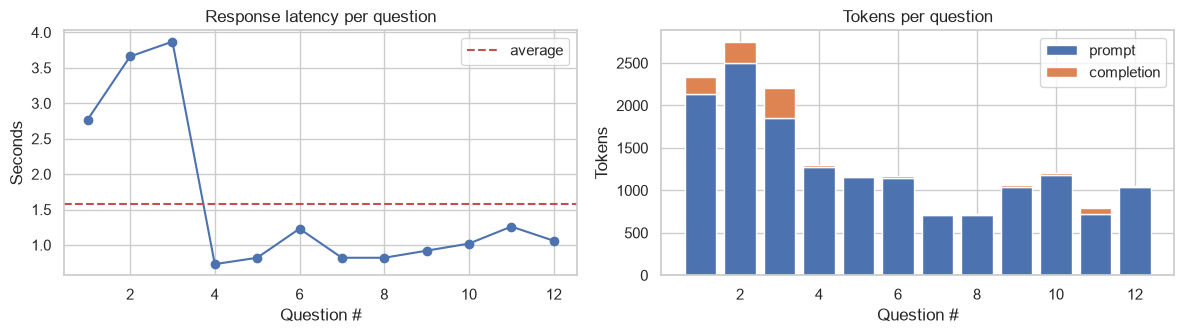

In [22]:
log = ifg.load_monitoring_log()
if log.empty:
    print("No questions logged yet.")
else:
    summary = ifg.monitoring_summary(log)
    display(pd.Series(summary).round(4).to_frame("value"))
    display(log.tail(10))
    ifg.plot_monitoring(log);

## 8. Data visualization

### 8.1 Sales trends over time

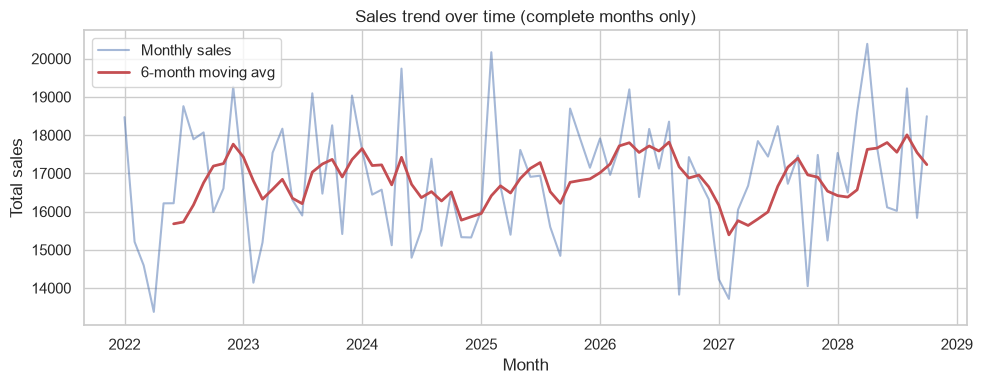

In [23]:
ifg.plot_sales_trend(df);

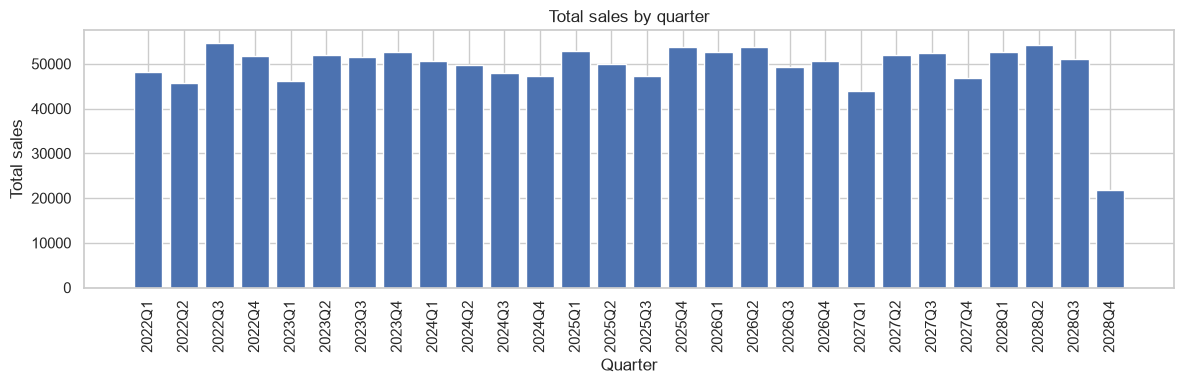

In [24]:
ifg.plot_quarterly_sales(df);

### 8.2 Product performance comparisons

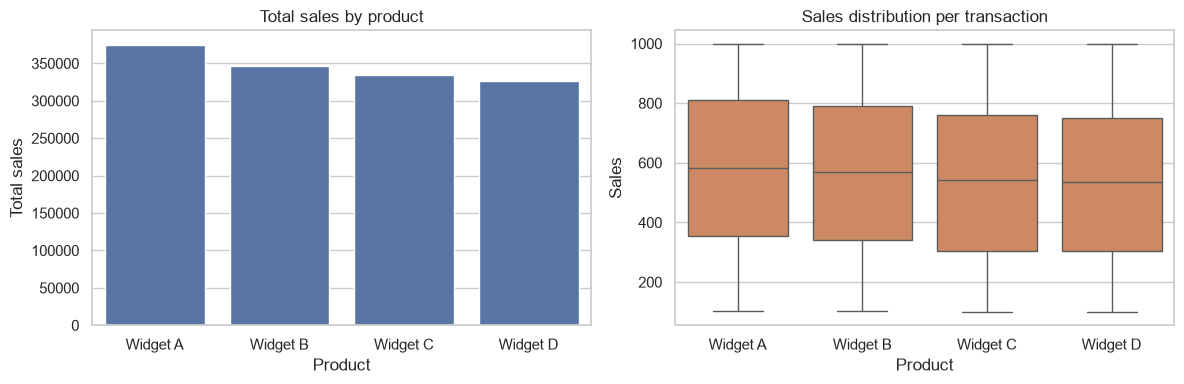

In [25]:
ifg.plot_product_performance(df);

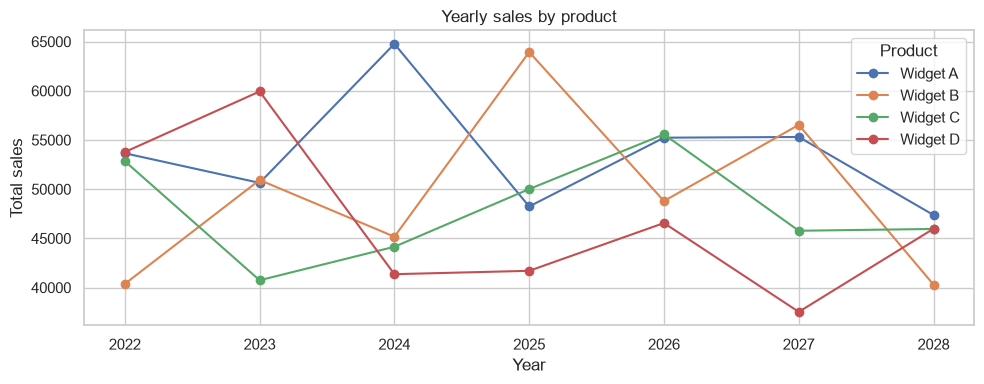

In [26]:
ifg.plot_product_trend(df);

### 8.3 Regional analysis

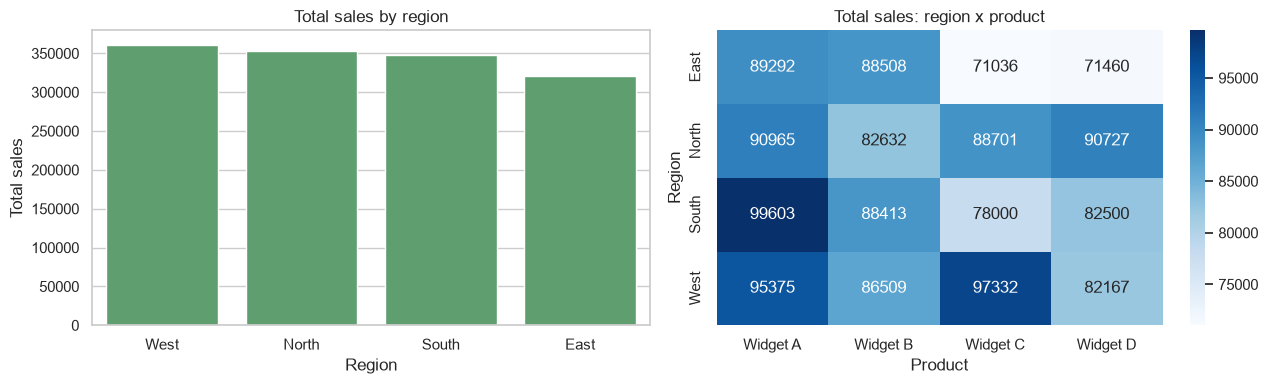

In [27]:
ifg.plot_regional_analysis(df);

### 8.4 Customer demographics and segmentation

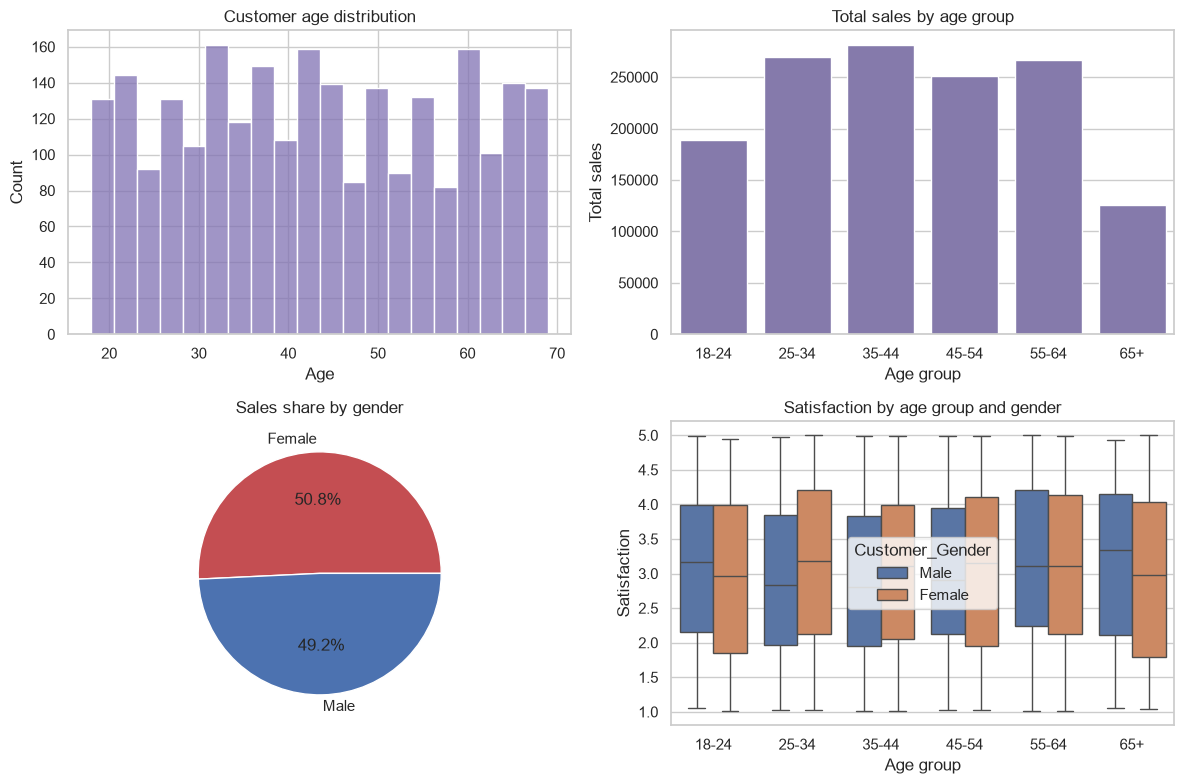

In [28]:
ifg.plot_demographics(df);

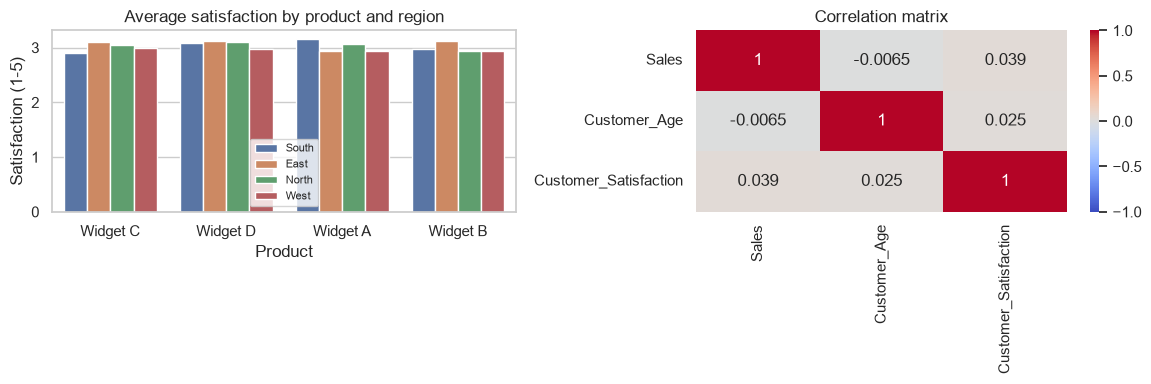

In [29]:
ifg.plot_satisfaction(df);

## 9. Streamlit UI
The interactive app is in `app.py`. Run it from this folder with:

```bash
streamlit run app.py
```
The OpenAI key is read from `.env` (or can be pasted into the sidebar).

It has five tabs: **Chat** (the AI assistant with memory), **Dashboard** (KPIs and all charts),
**Data Insights** (the computed summaries and raw data), **Evaluation** (runs QAEvalChain) and
**Monitoring** (latency, token usage, cost and errors for every question asked).

## 10. Key findings and conclusion
*(Numbers below come from the pandas summaries above.)*

- **Revenue:** 1.38M in total sales across 2,500 transactions (Jan 2022 to Nov 2028). The average
  transaction is about 553, with a high spread (std about 260).
- **Time:** yearly sales are broadly flat (roughly 195K to 206K per full year). The best full year
  is 2026 and there is no strong upward trend, so growth has to come from mix and targeting.
- **Products:** Widget A leads total sales and is the top product in the East, North and South.
  Widget C leads in the West.
- **Regions:** sales are spread fairly evenly across regions. East is the smallest, which makes it
  an expansion opportunity.
- **Customers:** customers aged 25 to 64 drive most of the revenue. Sales by gender are nearly equal.
- **Satisfaction:** the average is 3.0 out of 5, with almost no correlation to sales or age. This
  points to a service-quality opportunity across the board.

**Conclusion:** InsightForge combines pandas analytics, a custom retriever, PDF-based RAG, chained
prompts and conversational memory, with every answer monitored for latency, tokens and cost. The result is an assistant that gives accurate, explainable
answers, evaluated with QAEvalChain and delivered through a Streamlit interface. Possible next
steps: forecasting (for example Prophet or ARIMA), connecting live data sources, and a SQL agent
for ad-hoc queries.